# Part 9 — Cross-Area Representational Hierarchy

Tests whether the transient cross-mouse consistency observed in primary
visual cortex (VISp) propagates to or is amplified in downstream extrastriate,
thalamic, and hippocampal areas. Eight additional areas (VISl, VISal, VISpm,
VISam, VISrl, LP, LGd, CA1) are analysed with the same RSA pipeline used for
VISp throughout Parts 1–7.

Temporal curves are plotted in two panels, both referenced against VISp:
(A) VISp vs. the extrastriate visual cortical areas (VISl, VISal, VISpm,
    VISam, VISrl).
(B) VISp vs. the non-cortical areas (thalamus: LP, LGd; hippocampus: CA1).
Splitting the areas this way keeps each panel readable and shows whether the
transient structure of VISp is preserved, amplified, or flattened both
within extrastriate cortex and outside it. Per-area within-mouse response
reliability is reported separately as context (all areas ~0.93–0.98,
near-ceiling and broadly comparable) rather than used to normalise
consistency, since a properly RDM-scoped ceiling isn't computable for the
non-VISp areas with the cached data (see Part 1 Sec 1.3b).

Non-VISp within-mouse reliability values are precomputed in the preprocessing
notebook and stored inside `responses.h5` (see `ARCHIVE_CONTENTS.md` §3)
because their computation requires single-trial spike data not cached
elsewhere.

**Depends on:** `responses.h5` (all nine areas: natural-scenes tensors and
               non-VISp reliability values), `part1_outputs.npz` (VISp
               reliability and consistency), `part3_outputs.npz` (VISp
               temporal profile), `manifest.json`
**Outputs saved:** none (terminal notebook)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
    unit_matched_sliding_curve,
    usable_session_count,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

SEED = 42

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors      = apply_plot_style()
COL_FIT     = colors["COL_FIT"]           # peak annotations
COL_REF     = colors["COL_REF"]           # reference lines / baselines
AREA_COLORS = colors["AREA_COLORS"]       # nine-area palette (VISp == COL_DATA blue)
AREAS       = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam', 'VISrl', 'LP', 'LGd', 'CA1']

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES         = manifest['n_images']
AREA_SESSION_IDS = manifest['area_session_ids']
VISP_SESSION_IDS = manifest['selected_session_ids_visp']
AREAS            = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam', 'VISrl', 'LP', 'LGd', 'CA1']

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
visp_nc_per_session = p1['noise_ceiling']           # (32, 118)
visp_mean_nc        = visp_nc_per_session.mean()    # scalar

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
times_ms_visp     = p3['times_ms']
mean_c_visp       = p3['mean_c']
window_centers_ms = p3['window_centers_ms'].tolist()
WINDOW_WIDTH_MS   = float(p3['window_width_ms'])
peak_t_visp       = float(p3['peak_t'])
peak_c_visp       = float(p3['peak_c'])

SLIDE_START_MS = int(times_ms_visp.min())
SLIDE_END_MS   = int(times_ms_visp.max()) + 1

print(f'VISp: {len(VISP_SESSION_IDS)} sessions, '
      f'mean NC = {visp_mean_nc:.4f}, peak = {peak_c_visp:.4f}')
for area in AREAS[1:]:
    print(f'{area}: {len(AREA_SESSION_IDS.get(area, []))} sessions')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
VISp: 32 sessions, mean NC = 0.9778, peak = 0.3065
VISl: 24 sessions
VISal: 23 sessions
VISpm: 20 sessions
VISam: 26 sessions
VISrl: 28 sessions
LP: 19 sessions
LGd: 16 sessions
CA1: 25 sessions


## 9.1 — Load area tensors and noise ceilings from the archive

Area tensors are loaded one area at a time to avoid holding all nine areas in
memory simultaneously. Non-VISp noise ceilings are read directly from
`responses.h5` (precomputed during preprocessing; see `PREPROCESSING_STRATEGIES.md`
§4 for rationale). The VISp noise ceiling is taken from Part 1's output array.

In [3]:
area_noise_ceilings = {'VISp': visp_mean_nc}

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS[1:]:
        nc = f[f'natural_scenes/{area}/noise_ceiling'][:]  # (n_sessions, 118)
        area_noise_ceilings[area] = nc.mean()
        print(f'{area}: mean NC = {nc.mean():.4f}  '
              f'(n_sessions = {nc.shape[0]})')

print(f'\nNoise ceilings by area:')
for area in AREAS:
    print(f'  {area}: {area_noise_ceilings[area]:.4f}')

VISl: mean NC = 0.9644  (n_sessions = 24)
VISal: mean NC = 0.9743  (n_sessions = 23)
VISpm: mean NC = 0.9737  (n_sessions = 20)
VISam: mean NC = 0.9753  (n_sessions = 26)
VISrl: mean NC = 0.9695  (n_sessions = 28)
LP: mean NC = 0.9319  (n_sessions = 19)
LGd: mean NC = 0.9483  (n_sessions = 16)
CA1: mean NC = 0.9606  (n_sessions = 25)

Noise ceilings by area:
  VISp: 0.9778
  VISl: 0.9644
  VISal: 0.9743
  VISpm: 0.9737
  VISam: 0.9753
  VISrl: 0.9695
  LP: 0.9319
  LGd: 0.9483
  CA1: 0.9606


## 9.2 — Fixed-window (0–250 ms) consistency per area

For each area, the 32-session (or area-specific n-session) RSA pipeline is
applied to the 0–250 ms response matrix, giving raw per-image mean
consistency. Within-mouse response reliability is also reported per area as
context (all areas are near-ceiling and broadly comparable, ~0.96–0.98), but
consistency is reported as a raw Spearman r, not normalised by it.

In [4]:
T_LO_FIXED, T_HI_FIXED = 0, 250

area_consistency_fixed = {}   # area → scalar mean consistency

# VISp: use Part 1's fixed 0-250ms single-window consistency directly
# (same window_response -> compute_similarity_matrices -> per_image_consistency
# pipeline used for the non-VISp areas below), not the mean of the Part-3
# sliding-window curve -- those are different estimators and not comparable.
area_consistency_fixed['VISp'] = p1['consistency'].mean()

# Non-VISp areas: compute directly from their binned tensors
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS[1:]:
        sids = AREA_SESSION_IDS.get(area, [])
        if not sids:
            area_consistency_fixed[area] = np.nan
            continue
        mats = []
        for sid in sids:
            tensor = f[f'natural_scenes/{area}/{sid}/tensor'][:]
            X      = window_response(tensor, T_LO_FIXED, T_HI_FIXED)
            mats.append(X)
            del tensor
        sims      = compute_similarity_matrices(mats)
        c, _, _   = per_image_consistency(sims)
        area_consistency_fixed[area] = c.mean()
        gc.collect()

print('\nFixed-window (0–250 ms) mean consistency by area:')
for area in AREAS:
    c   = area_consistency_fixed[area]
    nc  = area_noise_ceilings[area]
    print(f'  {area}: r = {c:.4f}  (within-mouse reliability = {nc:.4f})')


Fixed-window (0–250 ms) mean consistency by area:
  VISp: r = 0.3142  (within-mouse reliability = 0.9778)
  VISl: r = 0.2022  (within-mouse reliability = 0.9644)
  VISal: r = 0.2485  (within-mouse reliability = 0.9743)
  VISpm: r = 0.2441  (within-mouse reliability = 0.9737)
  VISam: r = 0.2608  (within-mouse reliability = 0.9753)
  VISrl: r = 0.2107  (within-mouse reliability = 0.9695)
  LP: r = 0.1382  (within-mouse reliability = 0.9319)
  LGd: r = 0.0857  (within-mouse reliability = 0.9483)
  CA1: r = 0.0016  (within-mouse reliability = 0.9606)


## 9.3 — Sliding-window temporal profiles for all nine areas

The 25 ms / 10 ms-step sliding window from Part 3 is applied to each area.
Each area's curve uses the sessions available for that area
(session counts vary by area; see `manifest['area_session_ids']`).
Loading and discarding tensors per area avoids peak memory scaling with the
number of areas.

In [5]:
area_sliding_curves = {'VISp': (times_ms_visp, mean_c_visp)}

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS[1:]:
        sids = AREA_SESSION_IDS.get(area, [])
        if not sids:
            area_sliding_curves[area] = (np.array([]), np.array([]))
            continue

        # Load all sessions for this area into memory
        tensors_area = {}
        for sid in sids:
            tensors_area[sid] = f[f'natural_scenes/{area}/{sid}/tensor'][:]

        sliding = {}
        for t_ms in window_centers_ms:
            t_lo = t_ms - WINDOW_WIDTH_MS / 2
            t_hi = t_ms + WINDOW_WIDTH_MS / 2
            mats = [window_response(tensors_area[sid], t_lo, t_hi)
                    for sid in sids]
            sims = compute_similarity_matrices(mats)
            c, _, _ = per_image_consistency(sims)
            sliding[t_ms] = c.mean()

        t_arr = np.array(sorted(sliding))
        c_arr = np.array([sliding[t] for t in t_arr])
        area_sliding_curves[area] = (t_arr, c_arr)

        peak_area = c_arr[(t_arr >= 0) & (t_arr <= 250)].max()
        peak_t_area = t_arr[(t_arr >= 0) & (t_arr <= 250)][
            np.argmax(c_arr[(t_arr >= 0) & (t_arr <= 250)])
        ]
        print(f'{area}: peak = {peak_area:.4f} at {peak_t_area:.0f} ms')

        del tensors_area, sliding
        gc.collect()

VISl: peak = 0.1857 at 110 ms


VISal: peak = 0.2341 at 100 ms


VISpm: peak = 0.2097 at 120 ms


VISam: peak = 0.2380 at 110 ms


VISrl: peak = 0.1874 at 90 ms


LP: peak = 0.1401 at 90 ms


LGd: peak = 0.0921 at 80 ms


CA1: peak = 0.0015 at 190 ms


## 9.4 — Peak and T/S ratios by area

Report each area's raw sliding-window peak consistency (Spearman r).
Compute T/S ratio as peak consistency / sustained (220–250 ms) consistency,
identical to the convention used in Parts 3 and 5.

In [6]:
area_stats = {}

for area in AREAS:
    t_arr, c_arr = area_sliding_curves[area]
    if len(c_arr) == 0:
        area_stats[area] = dict(peak=np.nan, peak_t=np.nan, sust=np.nan, ts=np.nan)
        continue

    post_mask  = (t_arr >= 0) & (t_arr <= 250)
    sust_mask  = (t_arr >= 220) & (t_arr <= 250)
    peak_c_a   = c_arr[post_mask].max()
    peak_t_a   = t_arr[post_mask][np.argmax(c_arr[post_mask])]
    sust_a     = c_arr[sust_mask].mean() if sust_mask.any() else 0.0
    ts_a       = peak_c_a / (sust_a + 1e-8)

    area_stats[area] = dict(peak=peak_c_a, peak_t=peak_t_a, sust=sust_a, ts=ts_a)

print('\nArea summary statistics:')
print(f'{"Area":<6}  {"Peak r":>7}  {"Peak t(ms)":>10}  '
      f'{"Sust r":>7}  {"T/S":>5}')
print('-' * 45)
for area in AREAS:
    s = area_stats[area]
    print(f'{area:<6}  {s["peak"]:>7.4f}  {s["peak_t"]:>10.0f}  '
          f'{s["sust"]:>7.4f}  {s["ts"]:>5.2f}')


Area summary statistics:
Area     Peak r  Peak t(ms)   Sust r    T/S
---------------------------------------------
VISp     0.3065         100   0.1821   1.68
VISl     0.1857         110   0.0914   2.03
VISal    0.2341         100   0.1270   1.84
VISpm    0.2097         120   0.1203   1.74
VISam    0.2380         110   0.1187   2.00
VISrl    0.1874          90   0.0831   2.26
LP       0.1401          90   0.0484   2.90
LGd      0.0921          80   0.0496   1.86
CA1      0.0015         190   0.0000  33.23


## 9.4b — Unit-count- and session-count-matched control across areas

Areas differ in both per-session unit count and session count, either of
which can drive similarity-matrix SNR (and hence raw consistency)
independently of any genuine areal difference. Here every area's per-session
unit pool is randomly subsampled down to `target_n` (the smallest area's
mean per-session unit count) **and**, on every draw, the set of sessions
used is randomly subsampled down to `target_n_sessions` (the smallest
area's *usable* session count after applying the unit-count filter — some
areas lose sessions to that filter, so this can be smaller than any area's
raw session count), so unit count and session count are matched
simultaneously. The peak consistency (and its 95% bootstrap CI across
draws) is recomputed on the doubly-matched pools. Tensors are loaded and
discarded one area at a time to control peak memory, matching the pattern
used in 9.3.

In [7]:
N_DRAWS_AREA = 20

area_sids_map = {'VISp': VISP_SESSION_IDS, **{a: AREA_SESSION_IDS.get(a, []) for a in AREAS[1:]}}

# Cheap pass: per-session unit counts per area (shapes only, no full tensor read)
area_n_units = {}
area_idx_shapes = {}  # area -> {sid: list(range(n_units))}, for usable_session_count below
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS:
        sids = area_sids_map[area]
        counts = [f[f'natural_scenes/{area}/{sid}/tensor'].shape[1] for sid in sids]
        area_n_units[area] = counts
        area_idx_shapes[area] = {sid: list(range(n)) for sid, n in zip(sids, counts)}
        print(f'{area}: mean units/session = {np.mean(counts):.1f}  (n_sessions={len(counts)})')

target_n_area_match = int(round(min(np.mean(c) for c in area_n_units.values())))
print(f'\nSmallest area mean unit count -> target_n = {target_n_area_match} units/session')

# target_n_sessions must not exceed any area's *usable* session count after the
# unit-count filter (sessions with < target_n_area_match units are dropped
# before session-count matching, so the raw session count can overstate what's
# actually available -- e.g. a low-unit-count area can lose more sessions to
# the unit filter than its raw session-count minimum would suggest).
area_usable_sessions = {
    area: usable_session_count(area_idx_shapes[area], target_n_area_match)
    for area in AREAS
}
print('\nUsable sessions per area after unit-count filter (target_n = {}):'.format(target_n_area_match))
for area in AREAS:
    print(f'  {area}: {area_usable_sessions[area]} usable / {len(area_sids_map[area])} raw')

target_n_sessions_match = min(area_usable_sessions.values())
print(f'\nSmallest area usable-session count -> target_n_sessions = {target_n_sessions_match} sessions')

area_matched_stats = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS:
        sids = area_sids_map[area]
        if not sids:
            area_matched_stats[area] = dict(peak=np.nan, sust=np.nan, ts=np.nan,
                                             peak_draws=np.array([]))
            continue

        tensors_area = {sid: f[f'natural_scenes/{area}/{sid}/tensor'][:] for sid in sids}
        idx_area     = {sid: list(range(tensors_area[sid].shape[1])) for sid in sids}

        (t_match, c_match, ci_lo_match, ci_hi_match,
         ts_draws_match, peak_draws_match) = unit_matched_sliding_curve(
            tensors_area, idx_area, target_n_area_match,
            window_centers_ms, WINDOW_WIDTH_MS, n_draws=N_DRAWS_AREA, seed=SEED,
            target_n_sessions=target_n_sessions_match,
        )
        ts_match, pk_match, sus_match = ts_ratio(c_match, t_match)
        area_matched_stats[area] = dict(
            peak=pk_match, sust=sus_match, ts=ts_match, peak_draws=peak_draws_match,
            t_arr=t_match, c_arr=c_match,
        )
        print(f'{area}: matched peak={pk_match:.4f} '
              f'(draws: mean={peak_draws_match.mean():.4f}, '
              f'95% CI=[{np.percentile(peak_draws_match, 2.5):.4f}, '
              f'{np.percentile(peak_draws_match, 97.5):.4f}])')

        del tensors_area
        gc.collect()

print('\nRaw vs. unit-and-session-count-matched peak consistency '
      '(target_n = {} units/session, target_n_sessions = {} sessions):'.format(
          target_n_area_match, target_n_sessions_match))
print(f'{"Area":<6}  {"Raw peak":>8}  {"Matched peak":>12}  {"95% CI":>18}')
print('-' * 52)
for area in AREAS:
    pd_ = area_matched_stats[area]['peak_draws']
    if len(pd_) == 0:
        ci_str = 'n/a'
    else:
        ci_str = f'[{np.percentile(pd_, 2.5):.4f}, {np.percentile(pd_, 97.5):.4f}]'
    print(f'{area:<6}  {area_stats[area]["peak"]:>8.4f}  '
          f'{area_matched_stats[area]["peak"]:>12.4f}  {ci_str:>18}')

raw_order     = sorted(AREAS, key=lambda a: area_stats[a]['peak'], reverse=True)
matched_order = sorted(AREAS, key=lambda a: area_matched_stats[a]['peak'], reverse=True)
print(f'\nRaw peak ranking    : {raw_order}')
print(f'Matched peak ranking: {matched_order}')
print(f'Ranking preserved   : {raw_order == matched_order}')

VISp: mean units/session = 63.0  (n_sessions=32)
VISl: mean units/session = 38.9  (n_sessions=24)
VISal: mean units/session = 67.1  (n_sessions=23)
VISpm: mean units/session = 44.0  (n_sessions=20)
VISam: mean units/session = 57.9  (n_sessions=26)
VISrl: mean units/session = 50.5  (n_sessions=28)
LP: mean units/session = 75.6  (n_sessions=19)
LGd: mean units/session = 55.0  (n_sessions=16)
CA1: mean units/session = 97.4  (n_sessions=25)

Smallest area mean unit count -> target_n = 39 units/session

Usable sessions per area after unit-count filter (target_n = 39):
  VISp: 26 usable / 32 raw
  VISl: 12 usable / 24 raw
  VISal: 19 usable / 23 raw
  VISpm: 11 usable / 20 raw
  VISam: 21 usable / 26 raw
  VISrl: 20 usable / 28 raw
  LP: 14 usable / 19 raw
  LGd: 12 usable / 16 raw
  CA1: 23 usable / 25 raw

Smallest area usable-session count -> target_n_sessions = 11 sessions


VISp: matched peak=0.2752 (draws: mean=0.2764, 95% CI=[0.2295, 0.3344])


VISl: matched peak=0.1904 (draws: mean=0.1906, 95% CI=[0.1766, 0.2022])


VISal: matched peak=0.2103 (draws: mean=0.2113, 95% CI=[0.1789, 0.2444])


VISpm: matched peak=0.2406 (draws: mean=0.2406, 95% CI=[0.2253, 0.2513])


VISam: matched peak=0.1872 (draws: mean=0.1882, 95% CI=[0.1515, 0.2109])


VISrl: matched peak=0.1736 (draws: mean=0.1758, 95% CI=[0.1588, 0.2005])


LP: matched peak=0.1087 (draws: mean=0.1088, 95% CI=[0.0759, 0.1409])


LGd: matched peak=0.0847 (draws: mean=0.0866, 95% CI=[0.0789, 0.0972])


CA1: matched peak=0.0010 (draws: mean=0.0032, 95% CI=[0.0022, 0.0046])

Raw vs. unit-and-session-count-matched peak consistency (target_n = 39 units/session, target_n_sessions = 11 sessions):
Area    Raw peak  Matched peak              95% CI
----------------------------------------------------
VISp      0.3065        0.2752    [0.2295, 0.3344]
VISl      0.1857        0.1904    [0.1766, 0.2022]
VISal     0.2341        0.2103    [0.1789, 0.2444]
VISpm     0.2097        0.2406    [0.2253, 0.2513]
VISam     0.2380        0.1872    [0.1515, 0.2109]
VISrl     0.1874        0.1736    [0.1588, 0.2005]
LP        0.1401        0.1087    [0.0759, 0.1409]
LGd       0.0921        0.0847    [0.0789, 0.0972]
CA1       0.0015        0.0010    [0.0022, 0.0046]

Raw peak ranking    : ['VISp', 'VISam', 'VISal', 'VISpm', 'VISrl', 'VISl', 'LP', 'LGd', 'CA1']
Matched peak ranking: ['VISp', 'VISpm', 'VISal', 'VISl', 'VISam', 'VISrl', 'LP', 'LGd', 'CA1']
Ranking preserved   : False


---
## Figure

**Fig. 9** — Cross-mouse representational consistency is highest in V1 and
lower and roughly comparable across the extrastriate, thalamic, and
hippocampal areas. Panel A compares VISp to extrastriate visual cortex;
Panel B compares VISp to thalamus and hippocampus.


Fig 9B — Peak consistency and T/S ratio by area

--- area_labels ---
['VISp', 'VISl', 'VISal', 'VISpm', 'VISam', 'VISrl', 'LP', 'LGd', 'CA1']

--- peak_consistency ---
[0.30653  0.185684 0.234081 0.209675 0.23801  0.187397 0.140095 0.092095 0.001511]

--- transient_to_sustained_ratio ---
[ 1.683269  2.030738  1.843879  1.74263   2.004717  2.25507   2.89519   1.855159 33.232159]

--- within_mouse_reliability ---
[0.977762 0.964386 0.974333 0.973723 0.975291 0.969523 0.931928 0.948314 0.960565]

Fig 9A — Temporal profiles of cross-mouse consistency across all areas

--- area_labels ---
['VISp', 'VISl', 'VISal', 'VISpm', 'VISam', 'VISrl', 'LP', 'LGd', 'CA1']

--- VISp_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- VISl_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- VISal_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -1

C:\Users\janak\AppData\Local\Temp\ipykernel_36264\1141124343.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


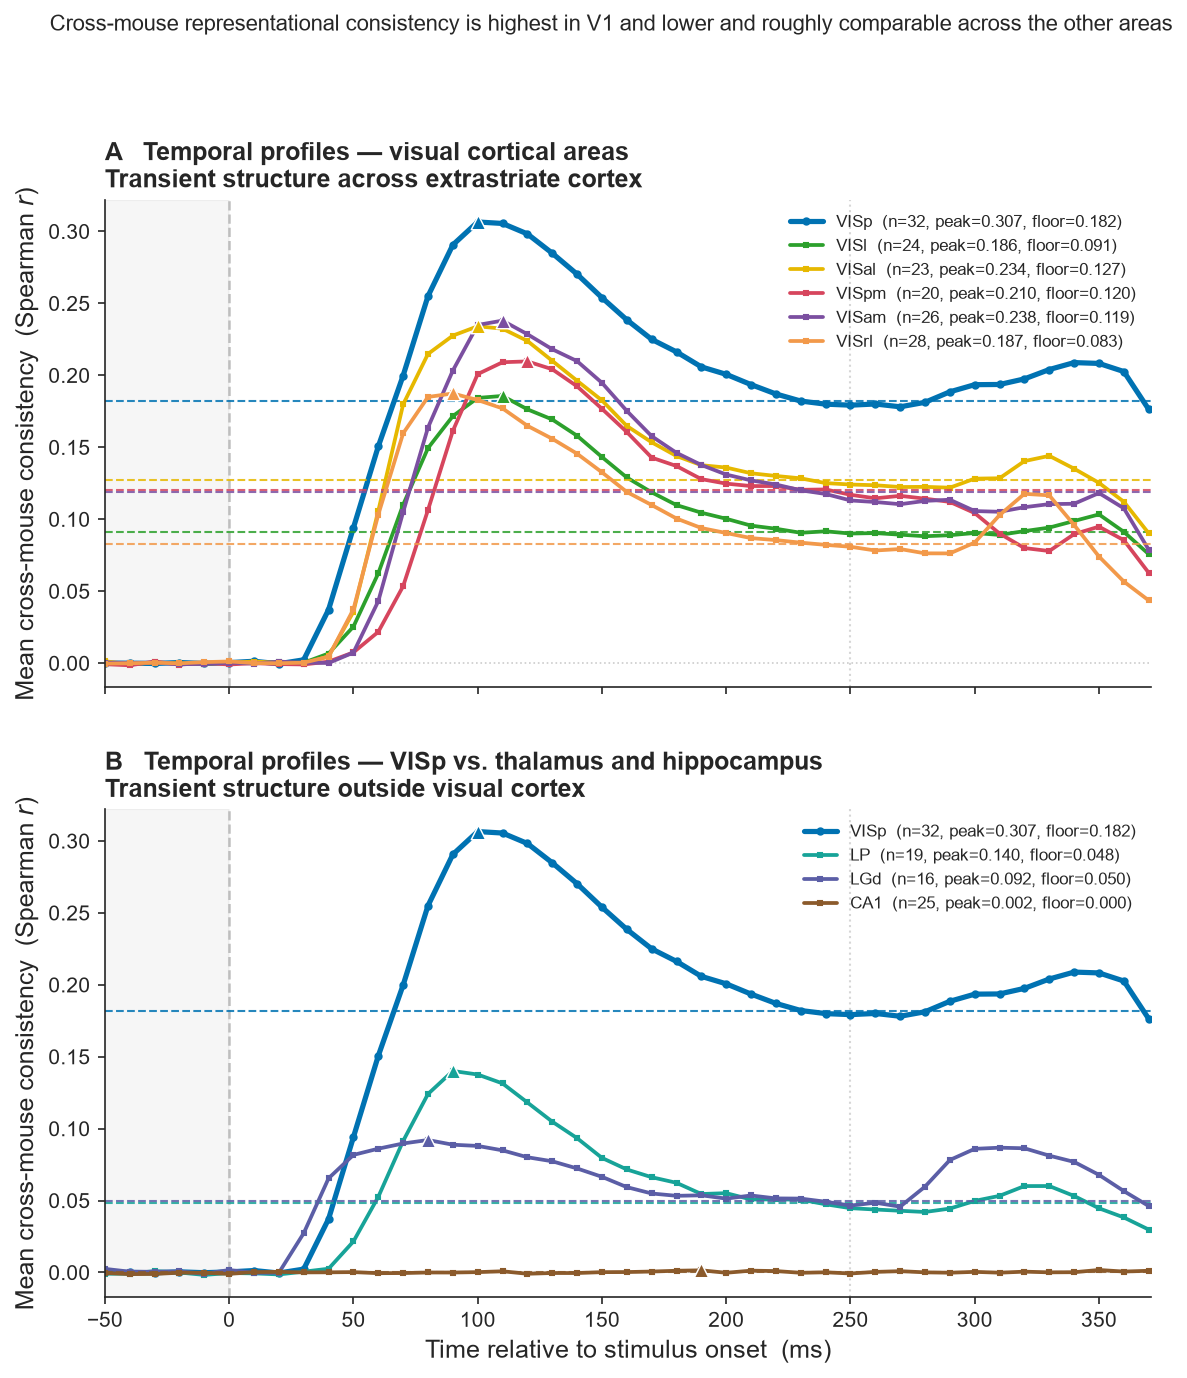

In [8]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 9.5), sharex=True,
                                     gridspec_kw={'hspace': 0.25})

def mark_peak_floor(ax, t, c, peak, sus, color, y_offset=None,
                    sustained_lo=220, sustained_hi=250):
    t = np.asarray(t)
    c = np.asarray(c)
    post_mask = (t >= 0) & (t <= 250)
    if np.any(post_mask):
        peak_t = t[post_mask][np.argmax(c[post_mask])]
    else:
        peak_t = t[np.argmax(c)]

    ax.scatter([peak_t], [peak], marker='^', s=48, color=color, zorder=6,
               edgecolor='white', linewidth=0.7)

    ax.hlines(sus, SLIDE_START_MS, SLIDE_END_MS,
              colors=color, linewidth=1.0, linestyle='--', alpha=0.85)
    if y_offset is None:
        y_offset = max(0.01, abs(peak) * 0.04)

peak_vals = [area_stats[a]['peak'] for a in AREAS]
ts_vals   = [area_stats[a]['ts']   for a in AREAS]

VISUAL_AREAS = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam', 'VISrl']
OTHER_AREAS  = ['VISp', 'LP', 'LGd', 'CA1']

def plot_area_panel(ax, areas, title):
    ax.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
    ax.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
    ax.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.0, alpha=0.4)
    ax.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)

    for area in areas:
        t_arr, c_arr = area_sliding_curves[area]
        if len(c_arr) == 0:
            continue
        n_sessions = len(AREA_SESSION_IDS.get(area, VISP_SESSION_IDS))
        lw    = 2.5 if area == 'VISp' else 1.8
        mkr   = 'o' if area == 'VISp' else 's'
        mksz  = 3.0 if area == 'VISp' else 2.0
        ax.plot(t_arr, c_arr, color=AREA_COLORS[area], linewidth=lw,
                linestyle='-', marker=mkr, markersize=mksz,
                label=f'{area}  (n={n_sessions}, peak={area_stats[area]["peak"]:.3f}, floor={area_stats[area]["sust"]:.3f})')
        mark_peak_floor(ax, t_arr, c_arr,
                        area_stats[area]['peak'], area_stats[area]['sust'],
                        AREA_COLORS[area])

    ax.set_ylabel('Mean cross-mouse consistency  (Spearman $r$)')
    ax.set_title(title, loc='left', fontweight='bold', pad=6)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
    ax.legend(frameon=False, fontsize=8, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

plot_area_panel(ax_top, VISUAL_AREAS,
                 'A   Temporal profiles — visual cortical areas\n'
                 'Transient structure across extrastriate cortex')
plot_area_panel(ax_bot, OTHER_AREAS,
                 'B   Temporal profiles — VISp vs. thalamus and hippocampus\n'
                 'Transient structure outside visual cortex')
ax_bot.set_xlabel('Time relative to stimulus onset  (ms)')

fig.suptitle('Cross-mouse representational consistency is highest in V1 and '
             'lower and roughly comparable across the other areas',
             fontsize=10.5, y=1.01)

print_figure_data(
    'Fig 9B — Peak consistency and T/S ratio by area',
    area_labels=AREAS,
    peak_consistency=np.array(peak_vals),
    transient_to_sustained_ratio=np.array(ts_vals),
    within_mouse_reliability=np.array([area_noise_ceilings[a] for a in AREAS]),
)
print_figure_data(
    'Fig 9A — Temporal profiles of cross-mouse consistency across all areas',
    area_labels=AREAS,
    **{f'{area}_times_ms': area_sliding_curves[area][0] for area in AREAS},
    **{f'{area}_mean_consistency': area_sliding_curves[area][1] for area in AREAS},
    peak_consistency_per_area=np.array([area_stats[a]['peak'] for a in AREAS]),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_cross_area_hierarchy.png', bbox_inches='tight')
plt.show()